<a href="https://colab.research.google.com/github/Tabatha651/METODOS_NUMERICOS/blob/main/MetodoDeBiseccion_05Oct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MÉTODO DE BISECCIÓN

Queremos resolver la ecuación $x^3 + 4x^2 - 10 = 0$ en el intervalo $[1, 2]$.

*Nota: Aunque el código está programado para construir y evaluar funciones polinómicas mediante la solicitud de sus coeficientes, utilizaremos esta función como ejemplo ilustrativo.*

Como requisito previo para el **MÉTODO DE BISECCIÓN**, comprobamos que la función continua $f(x)$ evaluada en los extremos del intervalo $[a,b]$ tiene signos opuestos, es decir:

$$f(a) \times f(b) < 0$$

El **Teorema del Valor Intermedio** nos asegura que existe al menos un número $p \in [a,b]$ tal que $p$ es una raíz de $f(x)$, es decir, $f(p)=0$.

Aproximaremos la solución calculando de manera iterativa el punto medio del intervalo, mediante la expresión:
$$p_i = \frac{b_i - a_i}{2}$$

In [3]:
### 04/oct/2026 - PRUEBA
from math import * #Importa funciones del módulo math
import numpy as np #Importa biblioteca Numphy y asigna el alias np
import matplotlib.pyplot as plt #Gráficos, usa alias plt

In [4]:
#ECUACIÓN
while True:
  try:
    grado=int(input("Ingrese el grado de la función: "))
    if grado<=0:
      print("El grado debe ser un número entero mayor a 0\nInténtelo de nuevo")
      continue  #Se repite el ciclo
    break
  except ValueError:
    print("No es un número entero\nInténtelo de nuevo")

coeficientes=[] #Esta es una lista, no una tupla
terminos_imp=[]

print("\nIngrese los coeficientes desde el grado mayor hasta el término independiente:\n")

for i in range(grado,-1,-1):            #range(inicio, fin, paso)     n, n-1,...,2,1,0

  while True:
    try:
      coef=float(input(f"Coeficiente de x^{i}: "))
      coeficientes.append(coef)

  #PARA IMPRIMIR EC
      #Formato según la potencia
      if coef==0:
        pass #Indica que no se hace nada si el coef es 0
      elif i==1:
        terminos_imp.append(f"{coef}x")
      elif i==0:
        terminos_imp.append(f"{coef}")
      else:
        terminos_imp.append(f"{coef}x^{i}")

      break

    except ValueError:
      print("Ingrese un número válido, ya sea entero o decimal")

ecuacion_texto = " + ".join(terminos_imp).replace(" + -"," - ")

print(f"f(x)={ecuacion_texto}\n")



Ingrese el grado de la función: 3

Ingrese los coeficientes desde el grado mayor hasta el término independiente:

Coeficiente de x^3: 1
Coeficiente de x^2: 4
Coeficiente de x^1: 0
Coeficiente de x^0: -10
f(x)=1.0x^3 + 4.0x^2 - 10.0



In [5]:
#FUNCIÓN
def f(x):
    #np.polyval evalúa automáticamente la lista de coeficientes en el valor de x
    return np.polyval(coeficientes, x) #Evalua desde el término con el grado más alto

In [6]:
#INTERVALOS
while True:
  try:
    a0=float(input("Ingrese el límite inferior del intervalo (a): "))
    b0=float(input("Ingrese el límite superior del intervalo (b): "))
    if a0>=b0:
      print(f"El límite inferior (a={a0}) debe ser menor que el límite superior (b={b0}) \nInténtelo de nuevo\n")
      continue
    break
  except ValueError:
    print("Ingrese números válidos para los intervalos")
print(f"El intervalo es: [{a0} , {b0}]")

Ingrese el límite inferior del intervalo (a): 1
Ingrese el límite superior del intervalo (b): 2
El intervalo es: [1.0 , 2.0]


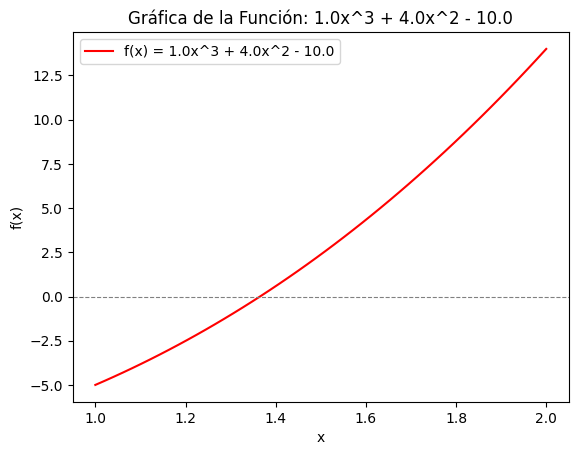

In [7]:
#GRÁFICA FUNCIÓN
xx=np.linspace(a0,b0) #Gráfica del intervalo [a,b]

#Graficamos la función usando la función f(x) previa
plt.plot(xx, f(xx), color="red", label=f"f(x) = {ecuacion_texto}")

plt.title(f"Gráfica de la Función: {ecuacion_texto}")
plt.xlabel("x")
plt.ylabel("f(x)")

plt.axhline(y=0, color='grey', linestyle='--', linewidth=0.8) #Línea horizontal (eje x)

#Muestra leyenda
plt.legend()

#Muestra gráfico
plt.show()

### GRÁFICA DE LA FUNCIÓN

La gráfica generada por el programa nos permite visualizar la función $f(x)$ dentro del intervalo $[a_0, b_0]$ antes de poder iniciar el proceso de iteración:

* **Eje de referencia ($y = 0$):** La línea punteada gris representa la intersección con el eje horizontal. La solución o raíz buscada es el punto exacto donde la función (la cual está en color rojo) cruza esta línea, es decir, donde $f(x)=0$.
* **Confirmación del Teorema del Valor Intermedio:** En la gráfica se puede apreciar cómo la función se desplaza desde una región con signo negativo hacia una con signo positivo (o viceversa) a lo largo del intervalo. Esto confirma de manera visual que $f(a)$ y $f(b)$ tienen signos opuestos, garantizando así la existencia de al menos una raíz en dicho intervalo.

In [8]:
#Guarda los valores iniciales de los intervalos
a=a0
b=b0

#Guardamos valores iniciales del error y del número de iteraciones
while True:
  try:
    tol=float(input("Ingrese el valor de la tolerancia: "))       #0.000001
    if tol<=0:
      print("El valor de tolerancia debe ser mayor a cero\n")
      continue
    nmax=int(input("Ingrese el número maximo de iteraciones: "))      #100
    if nmax<=0:
      print("El número máximo de iteraciones debe ser mayor a cero\n")
      continue
    break

  except ValueError:
    print("El valor ingresado no es válido\n")
    continue

error=abs(b-a)  #calulamos el error inicial (longitud del intervalo)
niter=0            #contador de iteraciones

##################################################################################

#MÉTODO DE BISECCIÓN

#Evaluamos el 1er valor medio
m=a+(b-a)/2

#Evaluamos la función en los puntos a, b y m:
fa=f(a)
fb=f(b)
fm=f(m)

#Impresión de tabla y de iteración núm 0
print("# iter\t\t a \t\t f(a) \t\t b \t\t f(b) \t\t m \t\t f(m) \t\t error")
print("{0} \t\t {1:6.4f} \t {2:6.4f} \t {3:6.4f} \t {4:6.4f} \t {5:6.4f} \t {6:6.4f} \t {7:6.4f}".format(niter, a0, fa, b0, fb, m, fm, error ))

#Ciclo de iteración
while error>tol and niter<nmax:   #Error supera la tolerancia y no excedemos el núm de iteraciones

  #si f(a) y f(m) tienen el mismo signo, la raíz está en [m, b]
  if np.sign(fa)==np.sign(fm):
    a=m
    fa=fm

  #la raíz está en [a, m]
  else:
    b=m
    fb=fm

  #reevaluamos punto medio
  m=(a+b)/2
  fm=f(m)

  #actualizamos el tamaño del nuevo intervalo (error) y el número de iteración
  error=abs(b-a)
  niter+=1
  print("{0} \t\t {1:6.6f} \t {2:6.6f} \t {3:6.6f} \t {4:6.6f} \t {5:6.6f} \t {6:6.6f} \t {7:6.6f}".format(niter, a, fa, b, fb, m, fm, error ))

print("\nLa raíz de la función dada en el intervalo [{0:6.4f},{1:6.4f}] es {2:6.7f}".format(a0,b0,m))

Ingrese el valor de la tolerancia: 0.000001
Ingrese el número maximo de iteraciones: 10000
# iter		 a 		 f(a) 		 b 		 f(b) 		 m 		 f(m) 		 error
0 		 1.0000 	 -5.0000 	 2.0000 	 14.0000 	 1.5000 	 2.3750 	 1.0000
1 		 1.000000 	 -5.000000 	 1.500000 	 2.375000 	 1.250000 	 -1.796875 	 0.500000
2 		 1.250000 	 -1.796875 	 1.500000 	 2.375000 	 1.375000 	 0.162109 	 0.250000
3 		 1.250000 	 -1.796875 	 1.375000 	 0.162109 	 1.312500 	 -0.848389 	 0.125000
4 		 1.312500 	 -0.848389 	 1.375000 	 0.162109 	 1.343750 	 -0.350983 	 0.062500
5 		 1.343750 	 -0.350983 	 1.375000 	 0.162109 	 1.359375 	 -0.096409 	 0.031250
6 		 1.359375 	 -0.096409 	 1.375000 	 0.162109 	 1.367188 	 0.032356 	 0.015625
7 		 1.359375 	 -0.096409 	 1.367188 	 0.032356 	 1.363281 	 -0.032150 	 0.007812
8 		 1.363281 	 -0.032150 	 1.367188 	 0.032356 	 1.365234 	 0.000072 	 0.003906
9 		 1.363281 	 -0.032150 	 1.365234 	 0.000072 	 1.364258 	 -0.016047 	 0.001953
10 		 1.364258 	 -0.016047 	 1.365234 	 0.000072 	 1

###MÉTODO BISECCIÓN

En cada iteración, nuestro código decide con cuál de las dos mitades del intervalo se queda ($[a, m]$ o $[m, b]$). Para hacerlo, evalúa si los signos de las funciones coinciden:

* **Si $\text{signo}(f(a)) == \text{signo}(f(m))$:**
  * El límite inferior se hace $a = m$
  * Si $f(a)$ y $f(m)$ tienen el mismo signo, significa que la función no ha cruzado por cero entre $a$ y $m$. Por el **Teorema del Valor Intermedio**, la raíz **no** está en el subintervalo $[a, m]$, sino se encuentra en $[m, b]$

* **Si $\text{signo}(f(a)) \neq \text{signo}(f(m))$:**
  * El límite superior se hace $b = m$
  * Si $f(a)$ y $f(m)$ tienen signos opuestos, se garantiza que el cruce por cero (la raíz) ocurre entre $a$ y $m$. Por lo tant, la raíz se encuentra en $[a, m]$

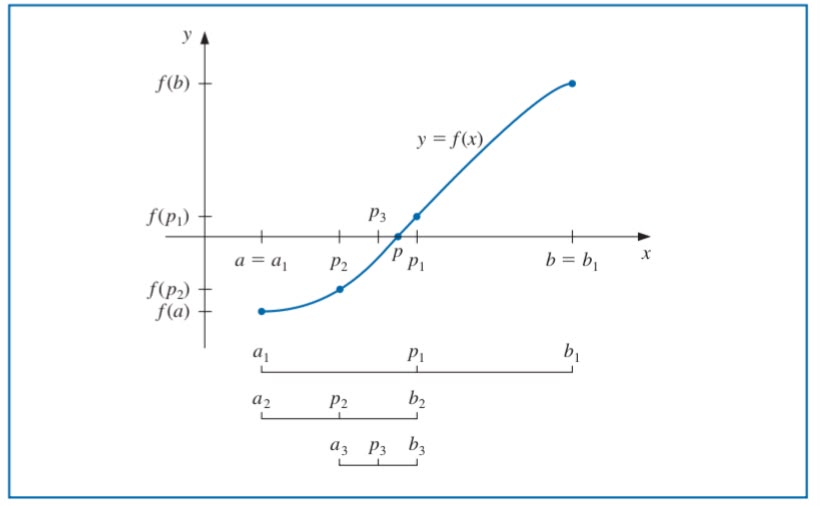

* **Error Absoluto ($\text{Error} = \vert{}b - a\vert{}$):**  
  Puesto que en cada paso el intervalo $[a, b]$ se reduce a la mitad, la longitud del intervalo actual representa la máxima distancia posible entre nuestro punto medio $m$ y la raíz real $p$. Definimos el error absoluto en cada iteración como la longitud del intervalo actual:
  $$\text{Error}_k = \vert{}b_k - a_k\vert{}$$

* **Tolerancia e Iteraciones Máximas:**  
  El ciclo "while" nos ayuda a evaluar dos condiciones:
  1. **Tolerancia ($\text{Error} \le \text{tol}$):** Detiene el programa cuando el error absoluto es menor o igual al valor fijado por el usuario (por ej: 0.000001), asegurando así la precisión requerida
  2. **Límite de Iteraciones ($k \ge \text{nmax}$):** Nos ayuda aa evitar ejecuciones infinitas si se define una tolerancia muy pequeña
